In [9]:
df = pd.read_html(PBS_FILE, header=0)[0]

print(df.columns.tolist())
print(df.head())

['Case Owner', 'Subject', 'Date/Time Opened', 'Age (Hours)', 'Open', 'Closed', 'Account Name', 'Case Origin']
      Case Owner                                            Subject  \
0  Laura Jenkins                 Inbound Call - Clinical Ultrasound   
1  Laura Jenkins                         Inbound Call - Okta Verify   
2  Laura Jenkins                 Inbound Call - Application Process   
3      Grace Koh                 Inbound Call - GD-CLINUS - Fee Due   
4      Grace Koh  Inbound Call - GD-CLINUS - Subject Timetable I...   

     Date/Time Opened  Age (Hours)  Open  Closed  \
0  24/02/2025 4:32 PM            0     0       1   
1  25/02/2025 9:34 AM            0     0       1   
2  25/02/2025 9:21 AM            1     0       1   
3  25/02/2025 1:25 PM            0     0       1   
4  25/02/2025 2:04 PM            0     0       1   

                                Account Name Case Origin  
0        Raheela Asif Administrative Account       Phone  
1     Maggie Davidson Administra

## 1. data clean

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

PBS_FILE = r"PBS - Autism Afferming Practice Salesforce Extract.xls"
TREATY_FILE = r"Understanding Treaty Salesforce Extract.xls"

def read_salesforce(file_path):

    try:
        df = pd.read_excel(file_path)
        print("Read as Excel")

    except:
        df = pd.read_html(file_path, header=0)[0]
        print("Read as HTML")

    df.columns = [str(col).strip() for col in df.columns]

    return df


# ============================================================

def clean_data(file_path, year, course):

    df = read_salesforce(file_path)

    print("\n==============================")
    print(course)
    print("==============================")

    print("Original data volume:", len(df))
    print("Col name:", df.columns.tolist())
    

    df = df.dropna(subset=["Subject"]).copy()

    df["Subject"] = (
        df["Subject"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    df = df[df["Subject"] != ""].copy()


    df["Date/Time Opened"] = pd.to_datetime(
        df["Date/Time Opened"],
        errors="coerce",
        dayfirst=True
    )

    df = df.dropna(subset=["Date/Time Opened"]).copy()
    
    
    df = df[
        df["Date/Time Opened"].dt.year == year
    ].copy()

    print(f"After the screening in {year}:", len(df))
    

    df["Subject_Normalized"] = (
        df["Subject"]
        .str.lower()
        .str.strip()
    )


    # --------------------------------------------------------
    # Deduplication principle: If the same Subject appears within 3 minutes, it is considered a duplicate.
    # --------------------------------------------------------

    df = df.sort_values(
        ["Subject_Normalized", "Date/Time Opened"]
    ).copy()

    df["Time_Diff_Minutes"] = (
        df.groupby("Subject_Normalized")["Date/Time Opened"]
        .diff()
        .dt.total_seconds()
        / 60
    )

    df["Is_Duplicate"] = (
        df["Time_Diff_Minutes"]
        .between(0, 3, inclusive="both")
    )


    print(
        df["Is_Duplicate"].sum()
    )

    # Save and check

    duplicates = df[
        df["Is_Duplicate"]
    ].copy()

    duplicates = (
        duplicates
        .sort_values(
            ["Subject_Normalized", "Date/Time Opened"]
        )
        .reset_index(drop=True)
    )

    df = df[
        ~df["Is_Duplicate"]
    ].copy()

    print(
        "Reduced data volume:",
        len(df)
    )

    df["Course"] = course
    duplicates["Course"] = course


    # primary key
    df["Case_Key"] = (
        df["Subject_Normalized"]
        + "_"
        + df["Date/Time Opened"].dt.strftime(
            "%Y-%m-%d_%H:%M:%S"
        )
    )

    df["Month"] = (
        df["Date/Time Opened"]
        .dt.to_period("M")
        .astype(str)
    )

    df["Weekday"] = (
        df["Date/Time Opened"]
        .dt.day_name()
    )

    if "Age (Hours)" in df.columns:

        df["Age_Hours"] = pd.to_numeric(
            df["Age (Hours)"],
            errors="coerce"
        )

    df = (
        df
        .sort_values("Date/Time Opened")
        .reset_index(drop=True)
    )

    return df, duplicates


In [6]:
pbs, pbs_duplicates = clean_data(
    PBS_FILE,
    2025,
    "PBS"
)

treaty, treaty_duplicates = clean_data(
    TREATY_FILE,
    2026,
    "Understanding Treaty"
)

pbs.to_excel(
    "PBS_2025_cleaned.xlsx",
    index=False
)

treaty.to_excel(
    "Treaty_2026_cleaned.xlsx",
    index=False
)

Read as HTML

PBS
Original data volume: 3380
Col name: ['Case Owner', 'Subject', 'Date/Time Opened', 'Age (Hours)', 'Open', 'Closed', 'Account Name', 'Case Origin']


C:\Users\Mao26\AppData\Local\Temp\ipykernel_11056\3615245594.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date/Time Opened"] = pd.to_datetime(


After the screening in 2025: 3378
16
Reduced data volume: 3362
Read as HTML

Understanding Treaty
Original data volume: 71
Col name: ['Subject', 'Date/Time Opened', 'Age (Hours)', 'Open', 'Closed', 'Course Name', 'Priority', 'Case Origin']
After the screening in 2026: 26
0
Reduced data volume: 26


C:\Users\Mao26\AppData\Local\Temp\ipykernel_11056\3615245594.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date/Time Opened"] = pd.to_datetime(


## 2. Data exploration

### 2.1 Word Cloud (student ask for?)

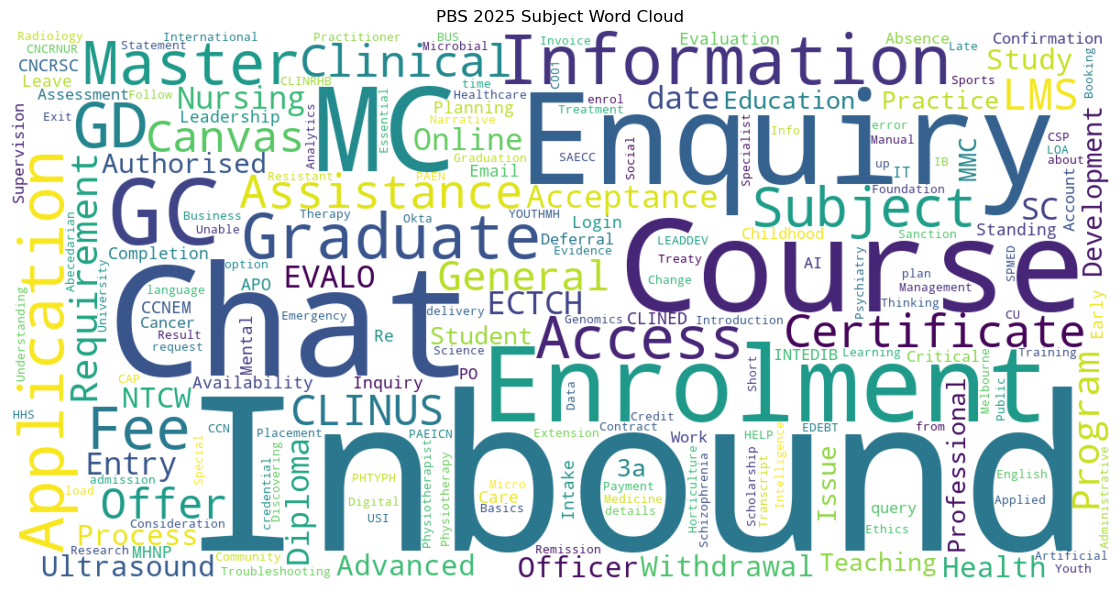

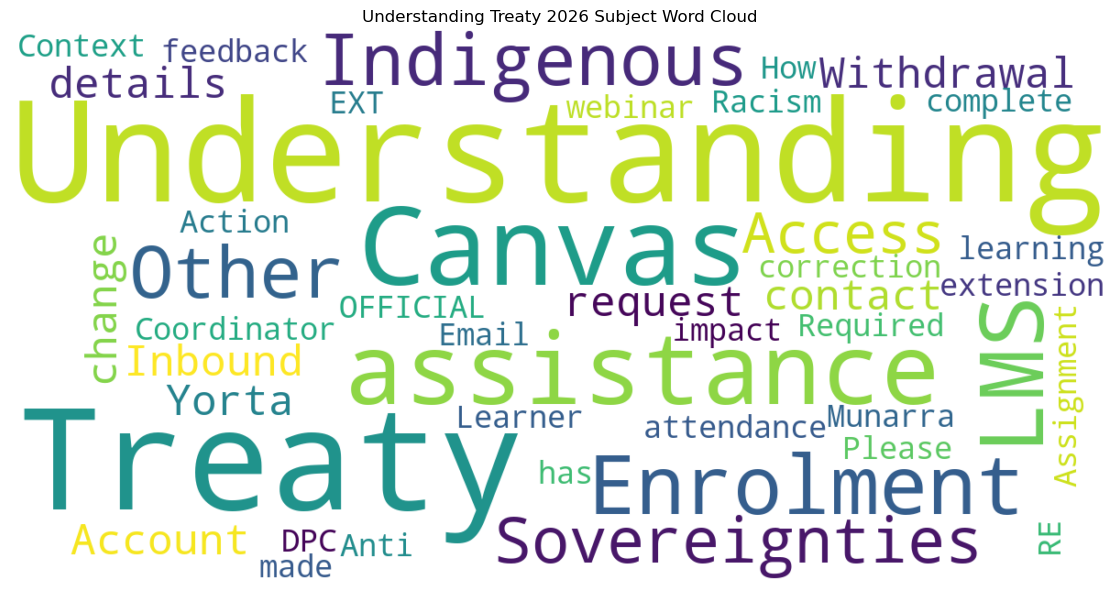

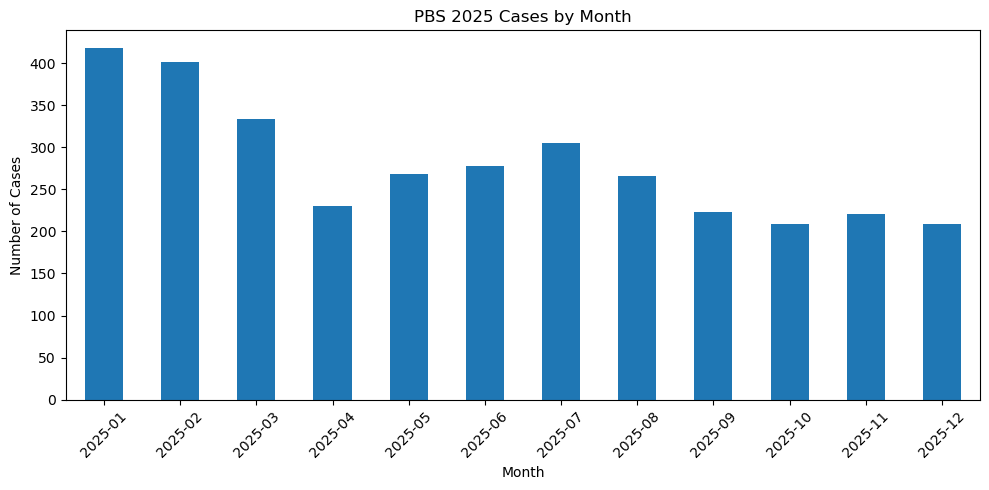

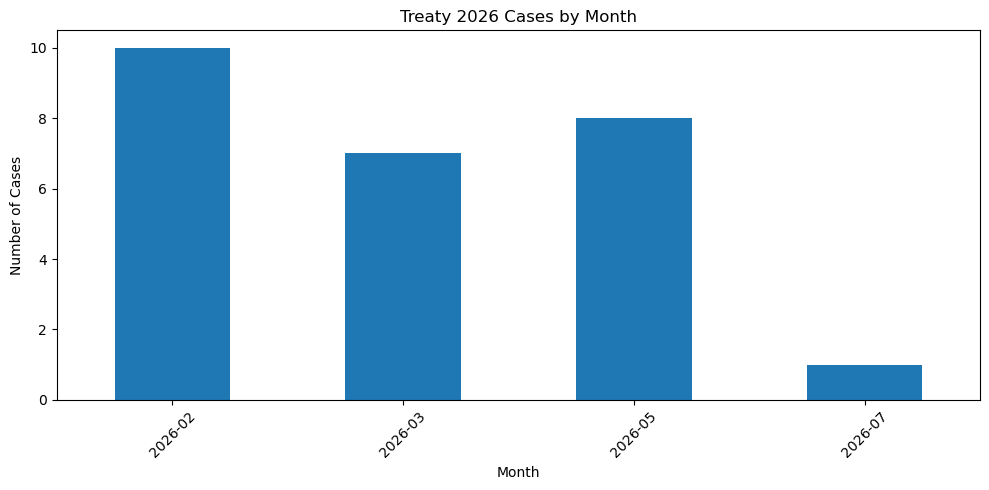

In [8]:

def plot_wordcloud(df, title):

    text = " ".join(
        df["Subject"]
        .dropna()
        .astype(str)
    )

    stopwords = {
        "the", "a", "an", "and", "or",
        "to", "of", "in", "for", "on",
        "with", "is", "are",
        "i", "my", "you", "your","call"
    }

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stopwords,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        wc,
        interpolation="bilinear"
    )

    plt.axis("off")
    plt.title(title)

    plt.tight_layout()
    plt.show()


plot_wordcloud(
    pbs,
    "PBS 2025 Subject Word Cloud"
)

plot_wordcloud(
    treaty,
    "Understanding Treaty 2026 Subject Word Cloud"
)


# Monthly Case Volume

def plot_monthly_cases(df, title):

    counts = (
        df["Month"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(10, 5))

    counts.plot(kind="bar")

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Number of Cases")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


plot_monthly_cases(
    pbs,
    "PBS 2025 Cases by Month"
)

plot_monthly_cases(
    treaty,
    "Treaty 2026 Cases by Month"
)

In [9]:
print("PBS columns:")
print(pbs.columns.tolist())

print("\nTreaty columns:")
print(treaty.columns.tolist())

PBS columns:
['Case Owner', 'Subject', 'Date/Time Opened', 'Age (Hours)', 'Open', 'Closed', 'Account Name', 'Case Origin', 'Subject_Normalized', 'Time_Diff_Minutes', 'Is_Duplicate', 'Course', 'Case_Key', 'Month', 'Weekday', 'Age_Hours']

Treaty columns:
['Subject', 'Date/Time Opened', 'Age (Hours)', 'Open', 'Closed', 'Course Name', 'Priority', 'Case Origin', 'Subject_Normalized', 'Time_Diff_Minutes', 'Is_Duplicate', 'Course', 'Case_Key', 'Month', 'Weekday', 'Age_Hours']


### 2.2 Case Origin × Age Boxplot

Are there differences in processing speeds among different consultation channels?

,Case Origin,Case_Count,Average_Age,Median_Age
0,Chat,1090,11.968807,0.0
1,In Person,6,15.500000,0.0
2,Phone,2266,31.182701,0.0


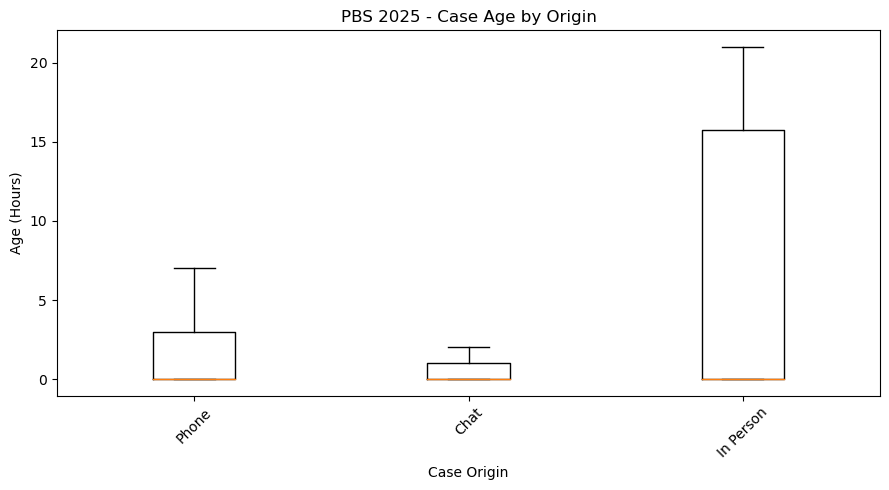

,Case Origin,Case_Count,Average_Age,Median_Age
0,Email,23,67.869565,21.0
1,Internal,1,0.000000,0.0
2,Phone,2,0.000000,0.0


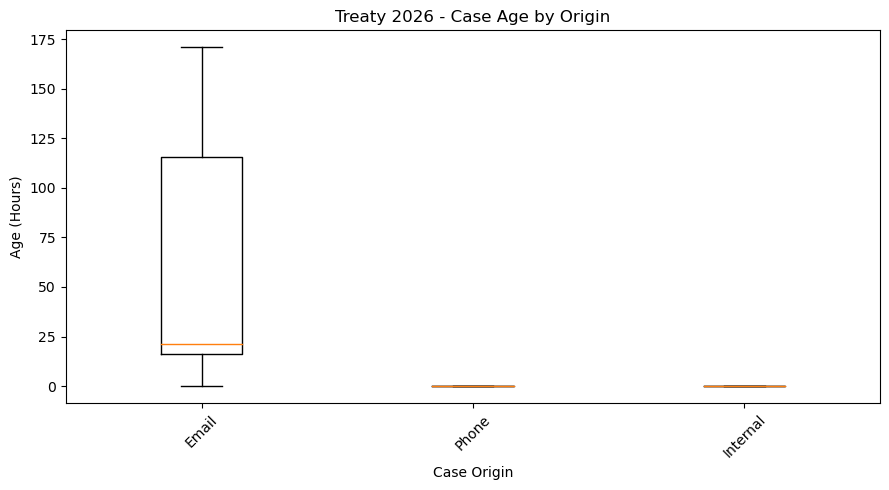

In [13]:
def plot_origin_age(df, title):
    age_limit = df["Age_Hours"].quantile(0.99)
    plot_df = df[df["Age_Hours"] <= age_limit].copy()

    origins = plot_df["Case Origin"].dropna().unique()
    age_data = [
        plot_df.loc[plot_df["Case Origin"] == origin, "Age_Hours"].dropna()
        for origin in origins
    ]

    summary = df.groupby("Case Origin").agg(
        Case_Count=("Case_Key", "count"),
        Average_Age=("Age_Hours", "mean"),
        Median_Age=("Age_Hours", "median")
    ).reset_index()

    display(summary)

    plt.figure(figsize=(9, 5))
    plt.boxplot(age_data, labels=origins, showfliers=False)
    plt.xlabel("Case Origin")
    plt.ylabel("Age (Hours)")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_origin_age(pbs, "PBS 2025 - Case Age by Origin")
plot_origin_age(treaty, "Treaty 2026 - Case Age by Origin")

### 2.3 Monthly Case Count + Average Age



,Month,Case_Count,Average_Age
0,2025-01,418,32.244019
1,2025-02,401,27.920200
2,2025-03,334,22.425150
3,2025-04,230,25.900000
4,2025-05,268,34.847015
5,2025-06,278,17.406475
6,2025-07,305,21.488525
7,2025-08,266,14.330827
8,2025-09,223,24.336323
9,2025-10,209,20.789474


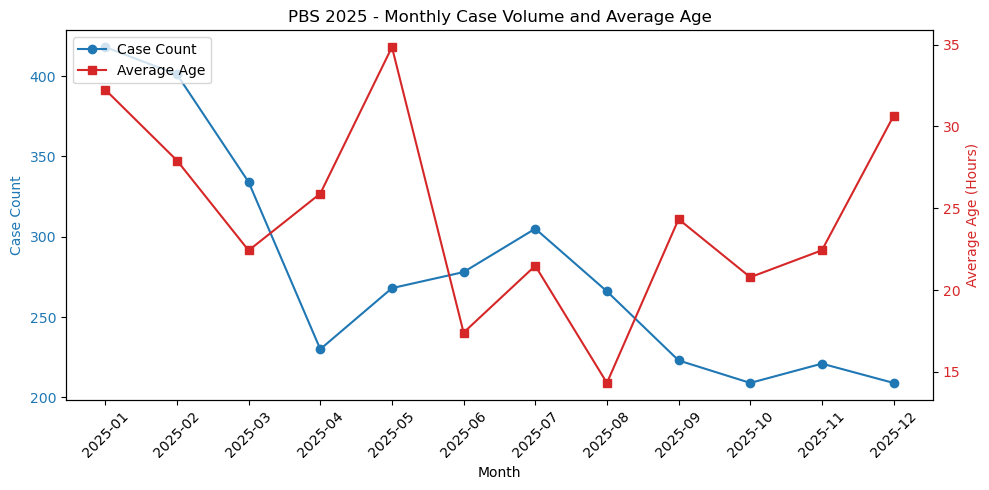

Pearson correlation: 0.25383066779385316


,Month,Case_Count,Average_Age
0,2026-02,10,66.50
1,2026-03,7,30.00
2,2026-05,8,85.75
3,2026-07,1,0.00


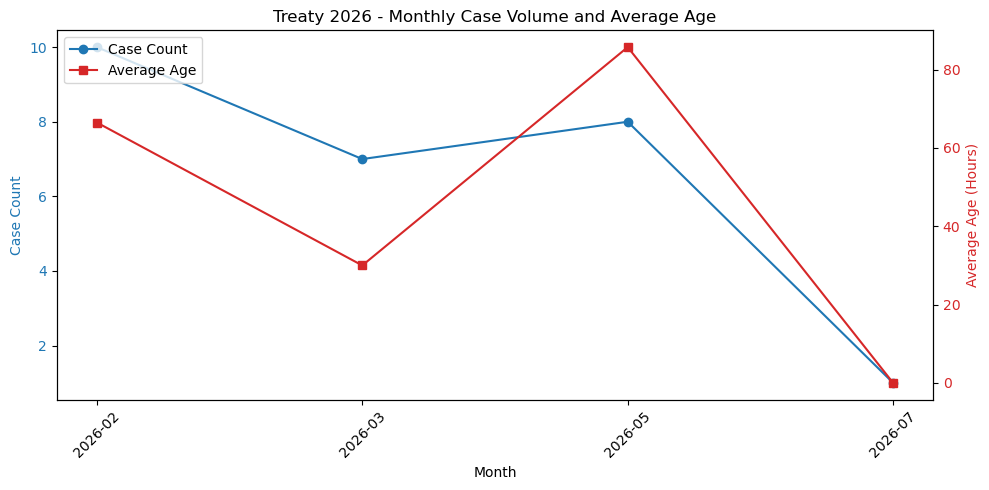

Pearson correlation: 0.8485881090053101


In [14]:
def plot_monthly_volume_age(df, title):
    monthly = df.groupby("Month").agg(
        Case_Count=("Case_Key", "count"),
        Average_Age=("Age_Hours", "mean")
    ).reset_index().sort_values("Month")

    display(monthly)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    line1 = ax1.plot(monthly["Month"], monthly["Case_Count"],
                     marker="o", color="tab:blue", label="Case Count")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Case Count", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    line2 = ax2.plot(monthly["Month"], monthly["Average_Age"],
                     marker="s", color="tab:red", label="Average Age")
    ax2.set_ylabel("Average Age (Hours)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    lines = line1 + line2
    ax1.legend(lines, [x.get_label() for x in lines], loc="upper left")

    plt.title(title)
    fig.tight_layout()
    plt.show()

    print("Pearson correlation:",
          monthly["Case_Count"].corr(monthly["Average_Age"]))


plot_monthly_volume_age(
    pbs,
    "PBS 2025 - Monthly Case Volume and Average Age"
)

plot_monthly_volume_age(
    treaty,
    "Treaty 2026 - Monthly Case Volume and Average Age"
)

In [17]:
import re
from collections import Counter

stopwords = {"the","a","an","and","or","to","of","in","for","on","with","is","are","i","my","you","your","call"}

def extract_words(text):
    words = re.findall(r"[A-Za-z]+", str(text).lower())
    return [w for w in words if w not in stopwords and len(w) > 2]

### 2.4 Month × Student Needs (Monthly Top keywords) 

,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
inbound,270,252,187,127,161,152,164,165,124,121,148,149
chat,77,94,77,53,54,72,102,86,74,59,55,38
enquiry,79,57,40,60,43,64,45,45,47,32,34,25
course,67,62,53,41,35,49,54,47,41,47,34,30
enrolment,79,42,39,30,32,37,58,31,16,22,47,49
information,34,42,31,14,12,27,22,23,26,33,20,14
graduate,23,23,20,4,4,15,34,17,26,25,26,24
application,42,21,11,17,21,31,16,7,13,11,19,20
master,30,27,17,7,8,22,18,10,17,24,26,14
access,15,28,37,28,24,7,10,34,10,11,9,4


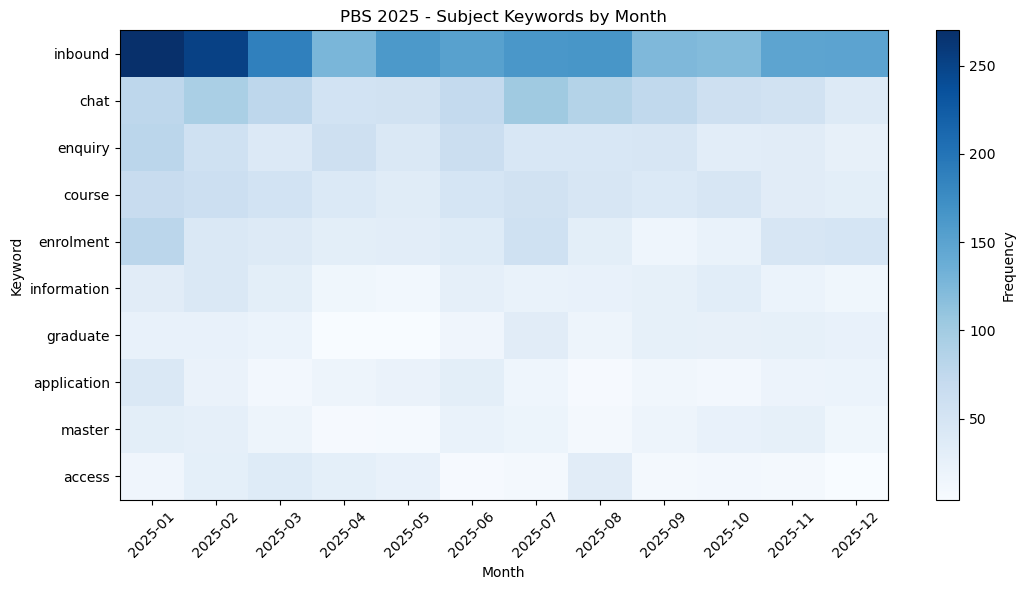

,2026-02,2026-03,2026-05,2026-07
understanding,10,7,2,1
treaty,10,7,2,1
canvas,7,4,0,0
assistance,5,0,4,0
lms,6,1,0,0
enrolment,1,0,5,0
indigenous,0,0,5,0
other,0,0,5,0
sovereignties,0,0,5,0
access,1,3,0,0


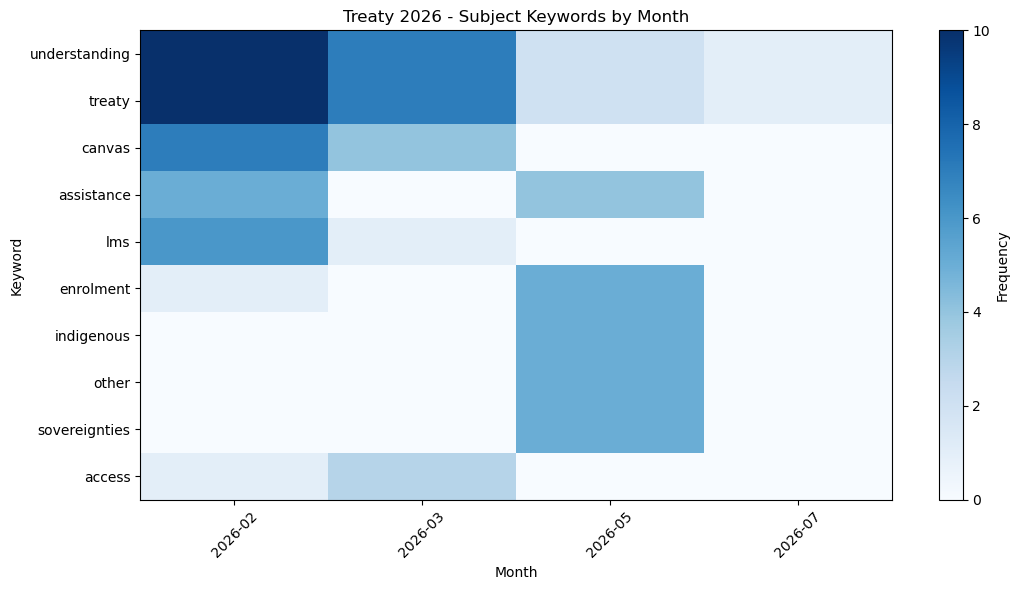

In [18]:
def plot_keyword_heatmap(df, title, top_n=10):
    all_words = []
    for subject in df["Subject"]:
        all_words.extend(extract_words(subject))

    top_words = [word for word, _ in Counter(all_words).most_common(top_n)]
    heatmap_data = pd.DataFrame(index=top_words)

    for month in sorted(df["Month"].unique()):
        month_words = []
        for subject in df.loc[df["Month"] == month, "Subject"]:
            month_words.extend(extract_words(subject))

        counts = Counter(month_words)
        heatmap_data[month] = [counts[word] for word in top_words]

    display(heatmap_data)

    plt.figure(figsize=(11, 6))
    plt.imshow(heatmap_data, aspect="auto", cmap="Blues")
    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.colorbar(label="Frequency")
    plt.xlabel("Month")
    plt.ylabel("Keyword")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_keyword_heatmap(
    pbs,
    "PBS 2025 - Subject Keywords by Month"
)

plot_keyword_heatmap(
    treaty,
    "Treaty 2026 - Subject Keywords by Month"
)

### 2.5 Weekday × Case Count + Average Age

,Weekday,Case_Count,Average_Age
0,Monday,770.0,18.825974
1,Tuesday,654.0,20.409786
2,Wednesday,721.0,22.506241
3,Thursday,569.0,36.912127
4,Friday,567.0,28.784832
5,Saturday,81.0,29.679012
6,Sunday,NaN,NaN


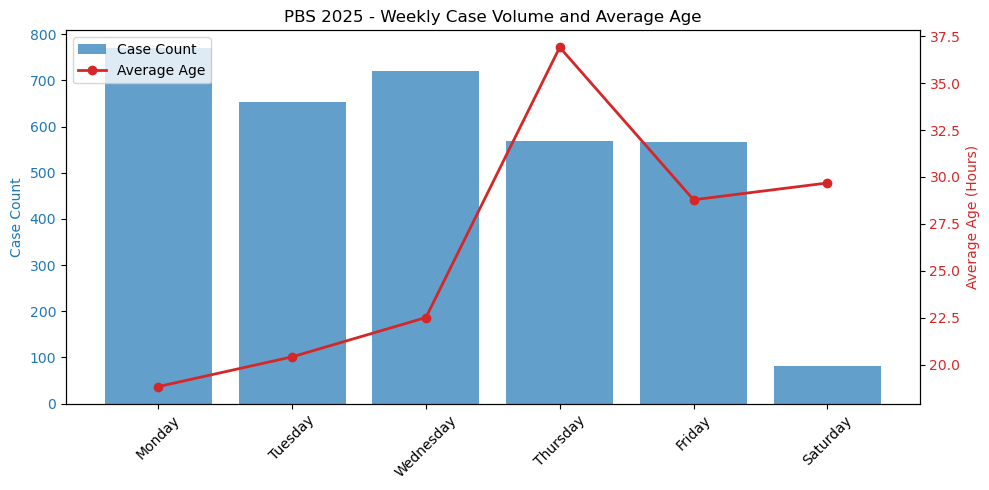

,Weekday,Case_Count,Average_Age
0,Monday,5.0,48.800000
1,Tuesday,4.0,16.500000
2,Wednesday,13.0,82.461538
3,Thursday,2.0,4.000000
4,Friday,2.0,85.500000
5,Saturday,NaN,NaN
6,Sunday,NaN,NaN


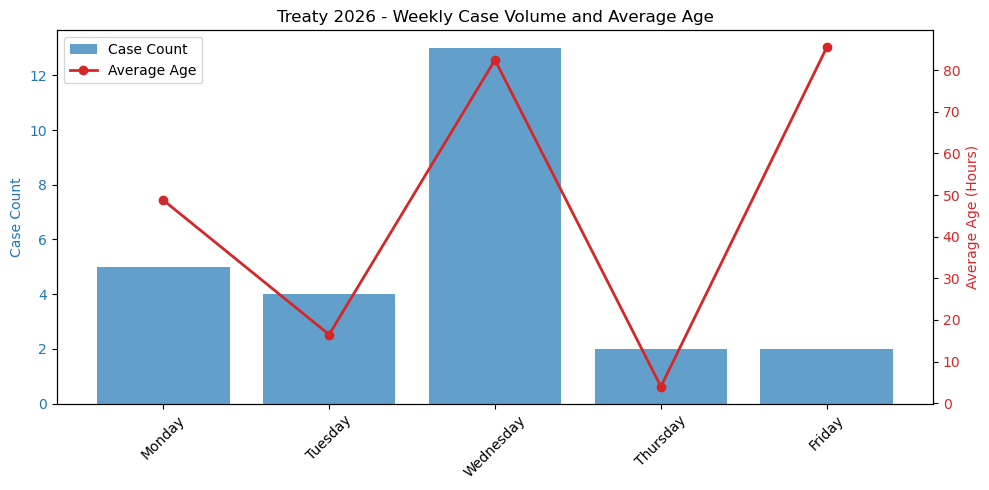

In [19]:
def plot_weekday_volume_age(df, title):
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

    weekday = df.groupby("Weekday").agg(
        Case_Count=("Case_Key", "count"),
        Average_Age=("Age_Hours", "mean")
    ).reindex(order).reset_index()

    display(weekday)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    bars = ax1.bar(weekday["Weekday"], weekday["Case_Count"],
                   color="tab:blue", alpha=0.7)
    ax1.set_ylabel("Case Count", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    line = ax2.plot(weekday["Weekday"], weekday["Average_Age"],
                    marker="o", color="tab:red", linewidth=2)
    ax2.set_ylabel("Average Age (Hours)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.legend([bars, line[0]], ["Case Count", "Average Age"], loc="upper left")

    plt.title(title)
    fig.tight_layout()
    plt.show()


plot_weekday_volume_age(
    pbs,
    "PBS 2025 - Weekly Case Volume and Average Age"
)

plot_weekday_volume_age(
    treaty,
    "Treaty 2026 - Weekly Case Volume and Average Age"
)